# Analyzing a rational agent

A rational agent acts optimally according to its internal model of the environment, even though that assumption can be different from reality.

Given the assumed environment parameter, we will get a family of rational agent using different seeds and the same learning procedure.

In [1]:
import sys
sys.path.append('/home/lokesh/OneDrive/Projects/irc-gym-AF/irc-gym-main/')

import matplotlib.pyplot as plt
import numpy as np

from irc import BeliefAgentFamily
# from irc.examples import FoodBoxEnv # to change to your custom environment
# bafam = BeliefAgentFamily(FoodBoxEnv)
from AF_env import AuditoryForaging # to change to your custom environment
bafam = BeliefAgentFamily(AuditoryForaging)

Default keyword arguments detected in cache/bafam_kwargs.json, and will be used as if not specified explicitly.
Belief agent family initialized, with environment parameters of dimension 3.


Environment parameters to be speficied is the tuple (lick cost, food reward, attention cost)

In [2]:
env_param = (-1., 3., -0.1)
seed = 0
agent, preview = bafam.optimal_agent(env_param, seed=seed)


0 works processed.
All works are processed or being processed.


Running imaginary episode using the internal model...


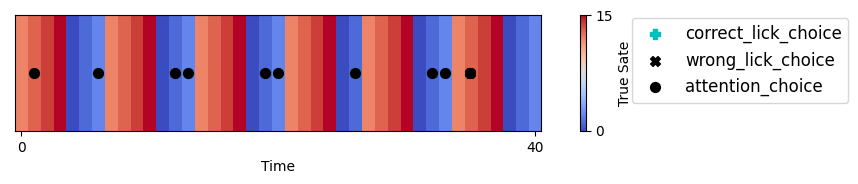

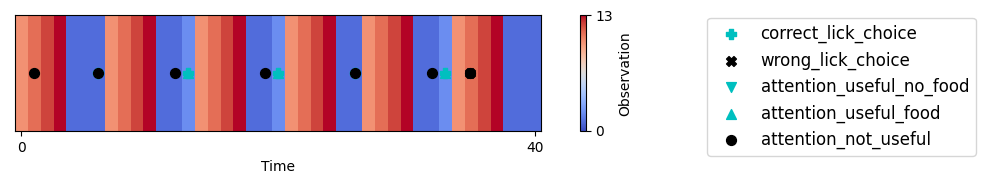

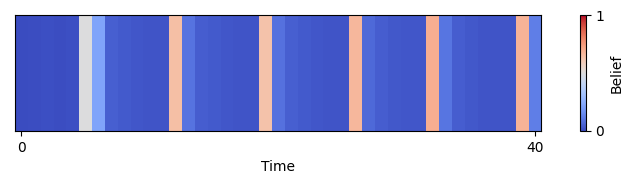

In [3]:
print("Running imaginary episode using the internal model...")
episode = agent.run_one_episode()

def plot_single_box_episode(episode, num_shades=None, num_states=None, figsize=(10, 1.5)):
    num_steps = episode['num_steps']
    states = episode['states']
    obss = episode['obss']
    actions = episode['actions']
    rewards = episode['rewards']
    assert not np.any(episode['q_states']-np.array([(1,)]))
    probs = episode['q_probs']
    if num_shades is None:
        num_shades = obss.max()
    if num_states is None:
        num_states = states.max()

    fig_w, fig_h = figsize
    aspect = num_steps*fig_h/fig_w*1.5
    figs = []

#     fig, ax = plt.subplots(figsize=figsize)
#     h = ax.imshow(
#         states.T, aspect=aspect, extent=[-0.5, num_steps+0.5, -0.5, 0.5],
#         vmin=0, vmax=1, origin='lower', cmap='coolwarm',
#     )
#     cbar = plt.colorbar(h, label='Has food')
#     cbar.set_ticks([0, 1])
#     cbar.set_ticklabels(['F', 'T'])
#     ax.set_xlim([-0.5, num_steps+0.5])
#     ax.set_xticks([0, num_steps])
#     ax.set_yticks([])
#     ax.set_xlabel('Time')
#     figs.append(fig)


    fig, ax = plt.subplots(figsize=figsize)
    h = ax.imshow(
        states.T, aspect=aspect, extent=[-0.5, num_steps+0.5, -0.5, 0.5],
        vmin=0, vmax=num_states, origin='lower', cmap='coolwarm',
    )
    cbar = plt.colorbar(h, label='True Sate')
    cbar.set_ticks([0, num_states])
#     cbar.set_ticklabels(['F', 'T'])
    idxs = ((actions==2)|(actions==3))&(rewards>=0)
    correct_lick_choice = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='c', marker='P', s=50)
    idxs = ((actions==2)|(actions==3))&(rewards<0)
    wrong_lick_choice = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='k', marker='X', s=50)
    idxs = (actions==1)|(actions==3)
    attention_choice = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='k', marker='o', s=50)
    ax.legend([correct_lick_choice,wrong_lick_choice,attention_useful_no_food,attention_useful_food,attention_not_useful], ['correct_lick_choice','wrong_lick_choice','attention_useful_no_food','attention_useful_food','attention_not_useful'], bbox_to_anchor=(1.3, 1.05), fontsize=12)
    ax.set_xlim([-0.5, num_steps+0.5])
    ax.set_xticks([0, num_steps])
    ax.set_yticks([])
    ax.set_xlabel('Time')
    figs.append(fig)
    
    

    fig, ax = plt.subplots(figsize=figsize)
    h = ax.imshow(
        obss.T, aspect=aspect, extent=[-0.5, num_steps+0.5, -0.5, 0.5],
        vmin=0, vmax=num_shades, origin='lower', cmap='coolwarm',
    )
    cbar = plt.colorbar(h, label='Observation')
    cbar.set_ticks([0, num_shades])
    idxs = ((actions==2)|(actions==3))&(rewards>=0)
    correct_lick_choice = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='c', marker='P', s=50)
    idxs = ((actions==2)|(actions==3))&(rewards<0)
    wrong_lick_choice = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='k', marker='X', s=50)
    idxs = ((actions==1)|(actions==3))&(obss.flatten(order='A')[0:len(actions)]==0)
    attention_useful_no_food = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='c', marker='v', s=50)
    idxs = ((actions==1)|(actions==3))&(obss.flatten(order='A')[0:len(actions)]==2)
    attention_useful_food = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='c', marker='^', s=50)
    idxs = ((actions==1)|(actions==3))&(obss.flatten(order='A')[0:len(actions)]!=0)&(obss.flatten(order='A')[0:len(actions)]!=2)
    attention_not_useful = ax.scatter(np.arange(num_steps)[idxs], np.zeros(sum(idxs)), color='k', marker='o', s=50)
    ax.legend([correct_lick_choice,wrong_lick_choice,attention_useful_no_food,attention_useful_food,attention_not_useful], ['correct_lick_choice','wrong_lick_choice','attention_useful_no_food','attention_useful_food','attention_not_useful'], bbox_to_anchor=(1.3, 1.05), fontsize=12)
    ax.set_xlim([-0.5, num_steps+0.5])
    ax.set_xticks([0, num_steps])
    ax.set_yticks([])
    ax.set_xlabel('Time')
    figs.append(fig)

    
    
    fig, ax = plt.subplots(figsize=figsize)
    h = ax.imshow(
        probs.T, aspect=aspect, extent=[-0.5, num_steps+0.5, -0.5, 0.5],
        vmin=0, vmax=1, origin='lower', cmap='coolwarm',
    )
    cbar = plt.colorbar(h, label='Belief')
    cbar.set_ticks([0, 1])
    ax.set_xlim([-0.5, num_steps+0.5])
    ax.set_xticks([0, num_steps])
    ax.set_yticks([])
    ax.set_xlabel('Time')
    figs.append(fig)
    return figs

figs = plot_single_box_episode(episode)

Training progress of reinforcement learning
Agent is evaluated on 10 episodes at each checkpoint, and return calculated over 40 time steps


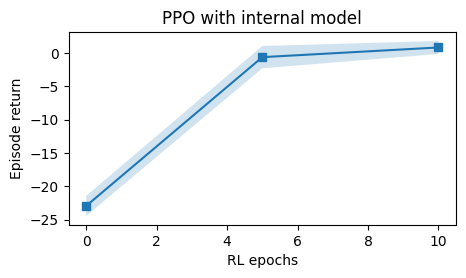

In [4]:
config = bafam.to_config(env_param=env_param, seed=seed)
_, ckpt, _ = bafam.load_ckpt(config)

num_episodes, num_steps = 10, 40
epochs, r_means, r_stds = [], [], []
for epoch, val in ckpt['eval_records'].items():
    epochs.append(epoch)
    r_means.append(np.mean(val['returns']))
    r_stds.append(np.std(val['returns']))
epochs = np.array(epochs)
r_means = np.array(r_means)
r_stds = np.array(r_stds)

print("Training progress of reinforcement learning")
print("Agent is evaluated on {} episodes at each checkpoint, and return calculated over {} time steps".format(num_episodes, num_steps))
_, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(epochs, r_means, marker='s')
ax.fill_between(epochs, r_means-r_stds/num_episodes**0.5, r_means+r_stds/num_episodes**0.5, alpha=0.2)
ax.set_xlabel('RL epochs')
ax.set_ylabel('Episode return')
ax.set_title('PPO with internal model')
plt.show()

## Log likelihood of the episode given assumed environment parameters

Multiple agent from the rational agent family can be fetched given the environment parameter, each denoted by its policy $\pi^{(i)}$. And to calculate the lilkelihood $p\left(o_{1:T}, a_{1:T}|\pi^{(i)}\right)$, multiple stochastic belief updates $b_{1:T}^{(j)}$ needs to be sampled. Therefore we will have an array of likelihoods $p\left(o_{1:T}, a_{1:T}|\pi^{(i)}, b_{1:T}^{(j)}\right)$ for each environment parameter.

In [ ]:
import pickle
with open('./cache/saved_episode.pickle',"wb") as f:
    pickle.dump({'episode':episode}, f)
episode_path = 'saved_episode.pickle'

In [ ]:
import matplotlib.pyplot as plt
from irc import BeliefAgentFamily
# from irc.examples import FoodBoxEnv # to change to your custom environment
# bafam = BeliefAgentFamily(FoodBoxEnv)
from AF_env import AuditoryForaging # to change to your custom environment
bafam = BeliefAgentFamily(AuditoryForaging)


from scipy.special import logsumexp

env_param = (-1., 3., -0.5)
max_seed, num_repeats = 6, 8
logps = bafam.episode_likelihood(env_param, episode_path, seeds=range(max_seed), num_repeats=num_repeats)

_, ax = plt.subplots(figsize=(5, 3))
h = ax.imshow(logps, cmap='summer')
plt.colorbar(h, label=r'$lnp(\bar{o},\bar{a}|\pi,\bar{b})$')
ax.set_xlabel('Belief traces index')
ax.set_ylabel('Agent index')
ax.set_title('Mean log likelihood {:.2f}'.format(logsumexp(logps)-np.log(logps.size)))
plt.show()

# Log likelihood for different environment parameters

We treat the expectation value of $p\left(o_{1:T}, a_{1:T}|\pi^{(i)}, b_{1:T}^{(j)}\right)$ over different agent instances and belief traces as the likelihood for one environment parameter $\theta$, and compute it for a set of environment parameters $\theta$s. Combining with a prior over $\theta$, we can calculate the posterior $p(\theta|o_{1:T}, a_{1:T})$.

In [ ]:
import numpy as np
from scipy.special import logsumexp

episode_path = 'saved_episode.pickle'

import matplotlib.pyplot as plt
from irc import BeliefAgentFamily
# from irc.examples import FoodBoxEnv # to change to your custom environment
# bafam = BeliefAgentFamily(FoodBoxEnv)
from AF_env import AuditoryForaging # to change to your custom environment
bafam = BeliefAgentFamily(AuditoryForaging)


import json
from itertools import product
import time
from jarvis.utils import progress_str, time_str

env_param = (0.05, 0.8, 10.)
max_seed, num_repeats = 2, 3

# with open('jsons/single_box_envs.json', 'r') as f:
#     envs_spec = json.load(f)


p_appear_list = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
p_cue_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
r_food_list = [2, 5, 10]
#Lokesh commented to check quick example
# p_appear_list = [0.05, 0.1]
# p_cue_list = [0.1, 0.2]
# r_food_list = [2, 5]

logps = np.zeros((len(p_appear_list), len(p_cue_list), len(r_food_list)))
print("Fetching episode log likelihood for all environment parameters...")
tic = time.time()
for idx, (i, j, k) in enumerate(product(range(len(p_appear_list)), range(len(p_cue_list)), range(len(r_food_list))), 1):
    env_param = (p_appear_list[i], p_cue_list[j], r_food_list[k])
    _logps = bafam.episode_likelihood(env_param, episode_path, seeds=range(max_seed), num_repeats=num_repeats)
    logps[i, j, k] = logsumexp(_logps)-np.log(_logps.size)
    
    if idx%(-(-logps.size//10))==0 or idx==logps.size:
        print('{} ({})'.format(progress_str(idx, logps.size), time_str(time.time()-tic, idx/logps.size)))

In [ ]:
print("true environment parameter:")
print(saved['true_env_spec'])

vmin, vmax = logps.min(), logps.max()
_, axes = plt.subplots(1, len(r_food_list), figsize=(5*len(r_food_list), 3))
for i, ax in enumerate(axes):
    h = ax.imshow(logps[..., i], vmin=vmin, vmax=vmax, cmap='summer')
    ax.set_xticks([0, len(p_cue_list)-1])
    ax.set_xticklabels([p_cue_list[0], p_cue_list[-1]])
    ax.set_xlabel(r'$p_\mathrm{cue}$')
    ax.set_yticks([0, len(p_appear_list)-1])
    if i==0:
        ax.set_yticklabels([p_appear_list[0], p_appear_list[-1]])
        ax.set_ylabel(r'$p_\mathrm{appear}$')
    else:
        ax.set_yticklabels([])
    ax.set_title(r'$r_\mathrm{food}$='+str(r_food_list[i]))
plt.colorbar(h, ax=axes, shrink=0.8, label=r'$\lnp(\bar{o},\bar{a}|\theta)$')
plt.show()